<h1 align=center style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
فیلتر تند و کند
</font>
</h1>

In [79]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
بخش اول: هموارسازی
</font>
</h2>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
در این بخش از تمرین قصد داریم با استفاده از یک فیلتر پایین‌گذر عملیات هموارسازی را بر روی یک تصویر نویزدار اعمال کنیم. هدف این است که تا حد امکان اثر نویز کاهش یابد و همچنین تصویر بسیار مات نشود.
</font>
</p>

<h3 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
مرحله اول: وارد کردن تصویر
</font>
</h3>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
ابتدا تصویر زیر را که در پوشه Data قرار دارد به شکل خاکستری وارد کنید.
    <br>
    choplin.png
</font>
</p>

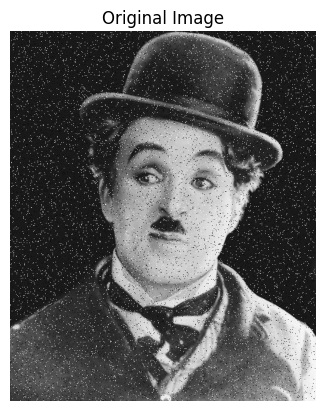

In [80]:
img1 = cv2.imread('./Data/choplin.png', cv2.IMREAD_GRAYSCALE)
plt.imshow(img1, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.show()


<h3 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
مرحله دوم: اعمال فیلتر پایین‌گذر
</font>
</h3>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
در این بخش ابتدا یک فیلتر پایین‌گذر را انتخاب کنید. سپس پارامترهای این فیلر را تنظیم کنید و آن را بر روی تصویر خود اعمال کنید. بر اساس انتخاب پارامترهای مختلف، تاثیر هر کدام را بر روی تصویر نهایی بررسی کنید و در نهایت تصویری که نویز آن کم است و در عین‌حال بسیار مات نشده را در نظر بگیرید.
</font>
</p>

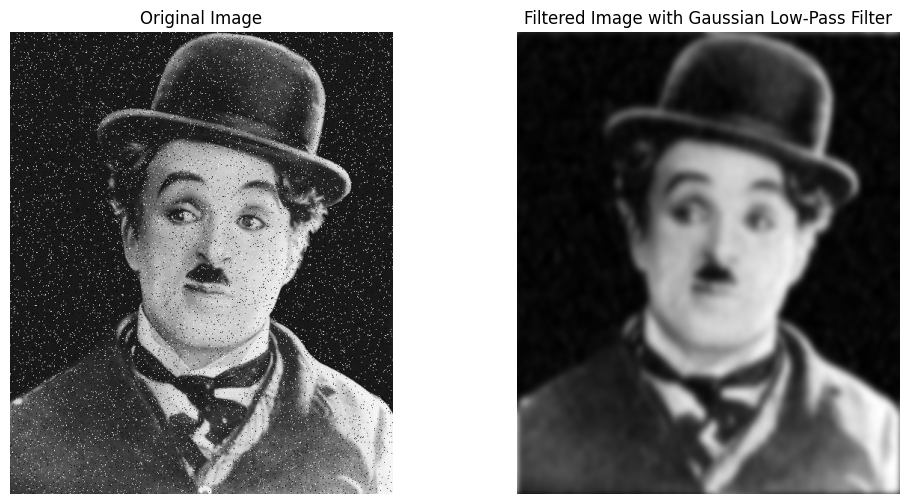

In [81]:
D0 = 20

# --- FFT (OpenCV style) ---
dft = cv2.dft(np.float32(img1), flags=cv2.DFT_COMPLEX_OUTPUT)
dft_shift = np.fft.fftshift(dft)

rows, cols = img1.shape
crow, ccol = rows // 2, cols // 2

# --- frequency grid ---
u = np.arange(cols) - ccol
v = np.arange(rows) - crow
U, V = np.meshgrid(u, v)
D = np.sqrt(U**2 + V**2)

# --- Gaussian Low-Pass Filter ---
H = np.exp(-(D**2) / (2 * (D0**2)))

# --- IMPORTANT: convert H to 2-channel for OpenCV ---
H = cv2.merge([H, H])     # == np.stack([H, H], axis=-1)

# --- Apply filter ---
filtered_dft_shift = dft_shift * H
filtered_dft = np.fft.ifftshift(filtered_dft_shift)

# --- Inverse FFT ---
img_back = cv2.idft(filtered_dft)
img_back = cv2.magnitude(img_back[:,:,0], img_back[:,:,1])

# --- Normalize ---
img_back = cv2.normalize(
    img_back, None, 0, 255,
    cv2.NORM_MINMAX, cv2.CV_8U
)


plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(img1, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(img_back, cmap='gray')
plt.title('Filtered Image with Gaussian Low-Pass Filter')
plt.axis('off')
plt.show()
# --- IGNORE ---

<h3 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
مرحله سوم: ذخیره‌سازی
</font>
</h3>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
در این بخش تصویر هموارسازی‌شده را ذخیره کنید. دقت کنید که تصویر را به حوزه رنگی  منتقل کرده و سپس آن را ذخیره کنید. تصویر را با نام زیر در کنار نوت‌بوک در پوشه تمرین ذخیره کنید.
<br>
choplin_smooth.png
</font>
</p>

(np.float64(-0.5), np.float64(511.5), np.float64(618.5), np.float64(-0.5))

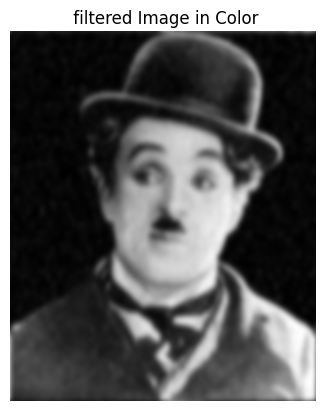

In [82]:
img1Color = cv2.cvtColor(img_back, cv2.COLOR_GRAY2BGR)
img1Color_RGB = cv2.cvtColor(img1Color, cv2.COLOR_BGR2RGB)
plt.imshow(img1Color_RGB)
plt.title(' filtered Image in Color')
plt.axis('off')

In [83]:
cv2.imwrite('choplin_smooth.png', img1Color)

True

<h2 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
بخش دوم: تیزسازی
</font>
</h2>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
در این بخش قصد داریم تا با استفاده از یک فیلتر بالاگذر بر روی تصویر خود عملیات تیزسازی را انجام دهیم. در ابتدا یک فیلتر بالاگذر را انتخاب کنید. سپس پارامترهای این فیلتر را تنظیم کنید به شکلی که تغییرات شدید در تصویر شما مثل لبه‌ها دارای وضوح بالاتری نسبت به سایر بخش‌های دیگر تصویر داشته باشند.
</font>
</p>

<h3 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
مرحله اول: وارد کردن تصویر
</font>
</h3>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
ابتدا تصویر زیر را که در پوشه Data قرار دارد به شکل خاکستری وارد کنید.
    <br>
light.jpg
</font>
</p>

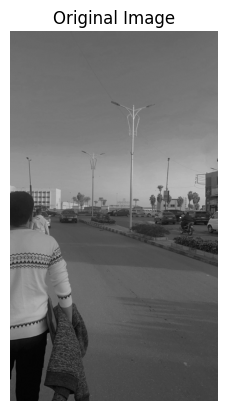

In [84]:
img2 = cv2.imread('./Data/light.jpg', cv2.IMREAD_GRAYSCALE)
plt.imshow(img2, cmap='gray')
plt.title('Original Image') 
plt.axis('off')
plt.show()


<h3 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
مرحله دوم: اعمال فیلتر بالاگذر
</font>
</h3>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
در این بخش ابتدا یک فیلتر بالاگذر را انتخاب کنید. سپس پارامترهای این فیلتر را تنظیم کنید به شکلی که تغییرات شدید تصویر بسیار واضح شوند. همچنین دقت شود که پارامترهای این فیلتر بالاگذر را طوری انتخاب کنید که جزئیات بی‌اهمیت را واضح نکند.
</font>
</p>

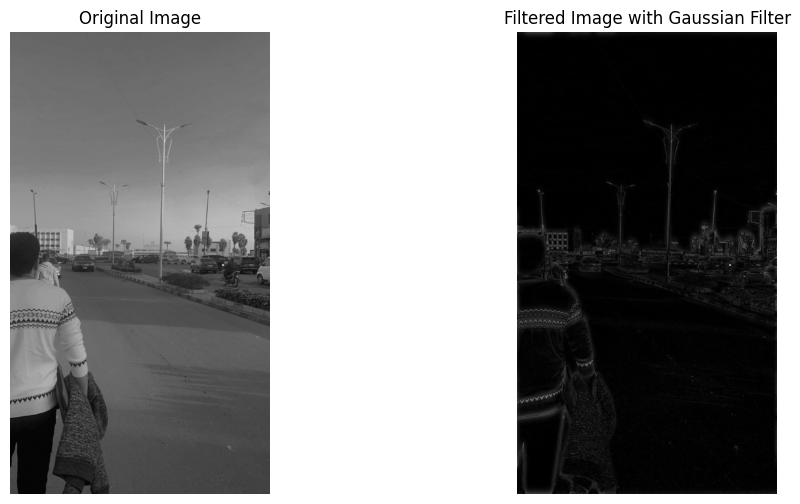

In [85]:
D0 = 20

# --- FFT (OpenCV style) ---
dft = cv2.dft(np.float32(img2), flags=cv2.DFT_COMPLEX_OUTPUT)
dft_shift = np.fft.fftshift(dft)

rows, cols = img2.shape
crow, ccol = rows // 2, cols // 2

# --- frequency grid ---
u = np.arange(cols) - ccol
v = np.arange(rows) - crow
U, V = np.meshgrid(u, v)
D = np.sqrt(U**2 + V**2)

# --- Gaussian Filter ---
H = 1 - np.exp(-(D**2)/(2*(D0**2)))

# --- IMPORTANT: convert H to 2-channel for OpenCV ---
H = cv2.merge([H, H])     # == np.stack([H, H], axis=-1)

# --- Apply filter ---
filtered_dft_shift = dft_shift * H
filtered_dft = np.fft.ifftshift(filtered_dft_shift)

# --- Inverse FFT ---
img_back = cv2.idft(filtered_dft)
img_back = cv2.magnitude(img_back[:,:,0], img_back[:,:,1])

# --- Normalize ---
img_back = cv2.normalize(
    img_back, None, 0, 255,
    cv2.NORM_MINMAX, cv2.CV_8U
)


plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(img2, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(img_back, cmap='gray')
plt.title('Filtered Image with Gaussian Filter')
plt.axis('off')
plt.show()
# --- IGNORE ---

<h3 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
مرحله سوم: ذخیره‌سازی
</font>
</h3>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
در این بخش تصویر تیزشده را ذخیره کنید. دقت کنید که تصویر را به حوزه رنگی  منتقل کرده و سپس آن را ذخیره کنید. تصویر را با نام زیر در کنار نوت‌بوک در پوشه تمرین ذخیره کنید.
<br>
light_sharp.jpg
</font>
</p>

(np.float64(-0.5), np.float64(1007.5), np.float64(1791.5), np.float64(-0.5))

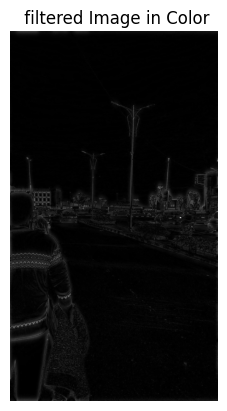

In [86]:
img2C0lor = cv2.cvtColor(img_back, cv2.COLOR_GRAY2BGR)
img2C0lor_RGB = cv2.cvtColor(img2C0lor, cv2.COLOR_BGR2RGB)
plt.imshow(img2C0lor_RGB)
plt.title(' filtered Image in Color')
plt.axis('off')


In [87]:
cv2.imwrite('light_sharp.jpg', img2C0lor)

True

<h3 align=right style="line-height:200%;font-family:vazir;color:#0099cc">
<font face="vazir" color="#0099cc">
مرحله پایانی: سلول جواب‌ساز
</font>
</h3>

<p dir=rtl style="direction: rtl;text-align: right;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
بدون هیچگونه تغییری، این سلول را اجرا کنید تا فایل پاسخ شما آماده شود.
</font>
</p>

In [88]:
import zipfile

def compress(file_names):
    print("File Paths:")
    print(file_names)
    # Select the compression mode ZIP_DEFLATED for compression
    # or zipfile.ZIP_STORED to just store the file
    compression = zipfile.ZIP_DEFLATED
    # create the zip file first parameter path/name, second mode
    with zipfile.ZipFile("result.zip", mode="w") as zf:
        for file_name in file_names:
            # Add file to the zip file
            # first parameter file to zip, second filename in zip
            zf.write('./' + file_name, file_name, compress_type=compression)


file_names = ["notebook.ipynb", "choplin_smooth.png", "light_sharp.jpg"]
compress(file_names)

File Paths:
['notebook.ipynb', 'choplin_smooth.png', 'light_sharp.jpg']
